## Imports

In [59]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Load data

In [60]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

# # Calculate min path dist; first set v high for the wrong people
# # Note: there's definitely a smarter way to do this in pandas
# test_df["fake_dist"] = test_df["trajs"].apply(len)
# test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

# test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

### Util fn, modular variant

In [84]:
from reeb_utils import collapse_traj, generate_reeb_tree, all_traj_same

def do_reeb_for_df(this_df, use_turns=True):
    # Check that all of the start nodes are the same
    assert len(set(this_df["StartAt"])) == 1
    
    trajs = []
    count = 0
    for _, row in this_df.iterrows():
        path = row["e_paths"] if use_turns else row["paths"]
        if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
        
        states = path.split()
        if not use_turns: states = collapse_traj(states)
        trajs.append(states)
        count += 1
        # if count == 15: break

    visited = {}

    G = nx.Graph()
    G.add_node(start_node + "_0", color="red", end=False)

    # print(start_node)
    # for t in trajs:
    #     print(t)
    generate_reeb_tree(0, start_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS=end_node[0], DEBUG=False)
    return G

def plot_treeb_special_path(G, special_edges):
    fig = plt.figure(figsize=(10,5))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .4 for u,v in edges]

    edge_colors = {}
    for edge in G.edges():
        if edge in special_edges:
            edge_colors[edge] = 'magenta'
        else:
            edge_colors[edge] = 'black'

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors.values(), width=weights, ax=this_ax)
    nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=this_ax) # font_weight="bold",

    this_ax.axis("off")
    plt.show()

## Try to predict individual success from location on Flow Tree

The thought is to create a Flow Tree with 70% of the data, will you be able to predit if an indiidual gets it right or wrong depending on where they are on the Flow Tree **before they finish**

In [91]:
def track_indiv_through_flow_tree(this_df, special_subject_number, use_turns=True, DEBUG=False):
    # Check that all of the start nodes are the same
    assert len(set(this_df["StartAt"])) == 1
    
    trajs = []
    accs = []
    count = 0
    indiv_idx = None
    for _, row in this_df.iterrows():
        # print(row["Subject"], special_subject_number, row["Subject"] == special_subject_number)
        if row["Subject"] == special_subject_number:
            indiv_idx = count
        path = row["e_paths"] if use_turns else row["paths"]
        if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
        
        states = path.split()
        if not use_turns: states = collapse_traj(states)
        trajs.append(states)
        accs.append(row["accuracy"])
        count += 1
        # if count == 15: break
    assert indiv_idx is not None
    
    visited = {}

    G = nx.Graph()
    G.add_node(start_node + "_0", color="red", end=False)

    special_visits = [start_node + "_0"]
    likelihoods_by_level = []
    track_indiv_generate_reeb_tree(0, start_node, trajs, [i for i in range(len(trajs))], G, visited, accs, special_visits=special_visits, likelihoods_by_level=likelihoods_by_level, special_idx=indiv_idx, SUCCESS=end_node[0], DEBUG=DEBUG)
    
    return G, special_visits, likelihoods_by_level

def track_indiv_generate_reeb_tree(start_i, start_node, trajs, which_trajs, G, visited, accs, special_visits=[], likelihoods_by_level=[], special_idx=-1, SUCCESS="", DEBUG=False):
    """Generates Reeb tree.

    TODO talk about what this means

    Parameters
    ----------
    start_i : TODO,
        TODO
    start_node : TODO,
        TODO
    trajs : list,
        Shape = [n_trajs, various]
        List of all trajectories over which to compute the Reeb tree.
    G : nx.Graph,
        Reeb tree to mutate in place as graph is construted.
    visited : TODO,
        TODO
    DEBUG : boolean,
        If True print more things.

    Returns
    -------
    None
    """
    if DEBUG: print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    max_traj_len = max([len(trajs[t]) for t in which_trajs])

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs, max_traj_len):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before
        
        end_node +=  "_" + str(times_before)
        if DEBUG: print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs))


        if special_idx in which_trajs:
            if DEBUG: print("IN BC", special_idx, which_trajs)
            special_visits.append(end_node)
            likelihood = np.mean([accs[z] for z in which_trajs[:-1]])
            likelihoods_by_level.append(likelihood)
            if DEBUG: print(special_visits)

        return
    

    ## RECURSIVE STEP ##
    if DEBUG: print(f"FOR LOOP, {start_i}, {which_trajs}")
    for step in range(start_i, max_traj_len):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        if DEBUG: print("NEW_GN", new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
            old_one = trajs[which_trajs[0]][step-1]
            times_before = visited.get(old_one, -1) + 1
            visited[old_one] = times_before
            
            on = old_one + "_" + str(times_before)
            G.add_node(on, color="blue", end=False)
            if DEBUG: print(f"ADDING NEW BLUE NODE {on}")
            
            G.add_edge(sn, on, weight=len(which_trajs))
            if DEBUG: print(f"ADDING NEW EDGE from {sn} to {on}, weight is {len(which_trajs)}")

            if special_idx in which_trajs:
                if DEBUG: print("IN RECURSE", special_idx, which_trajs)
                special_visits.append(on)
                likelihood = np.mean([accs[z] for z in which_trajs[:-1]])
                likelihoods_by_level.append(likelihood)
                if DEBUG: print(special_visits)
            
            for k, v in new_gn.items():
                if DEBUG: print("RECURSE")
                if DEBUG and k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                track_indiv_generate_reeb_tree(step+1, old_one, trajs,  v, G, visited, accs, special_visits=special_visits, likelihoods_by_level=likelihoods_by_level, special_idx=special_idx, SUCCESS=SUCCESS, DEBUG=DEBUG)

            return

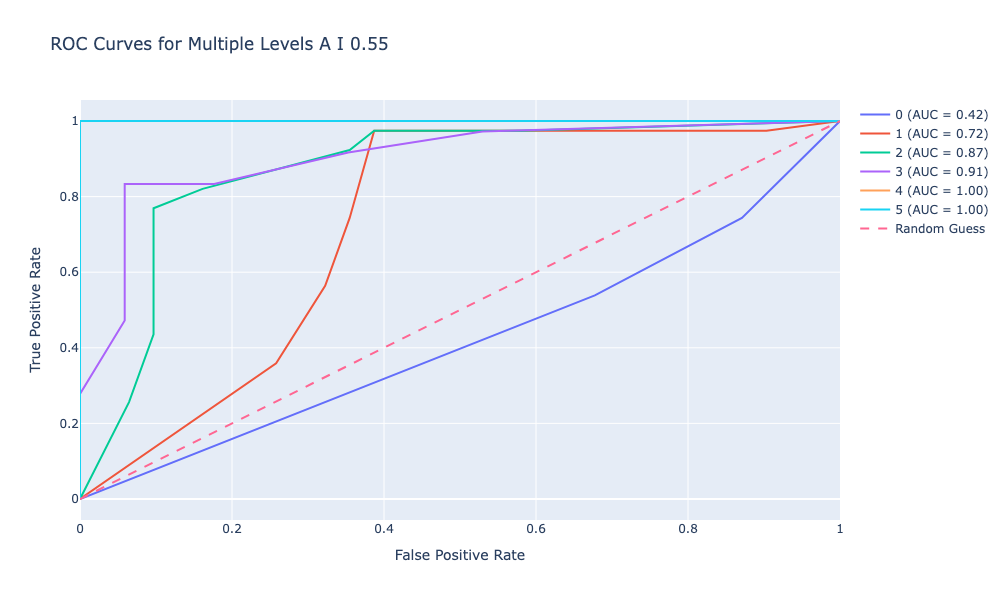

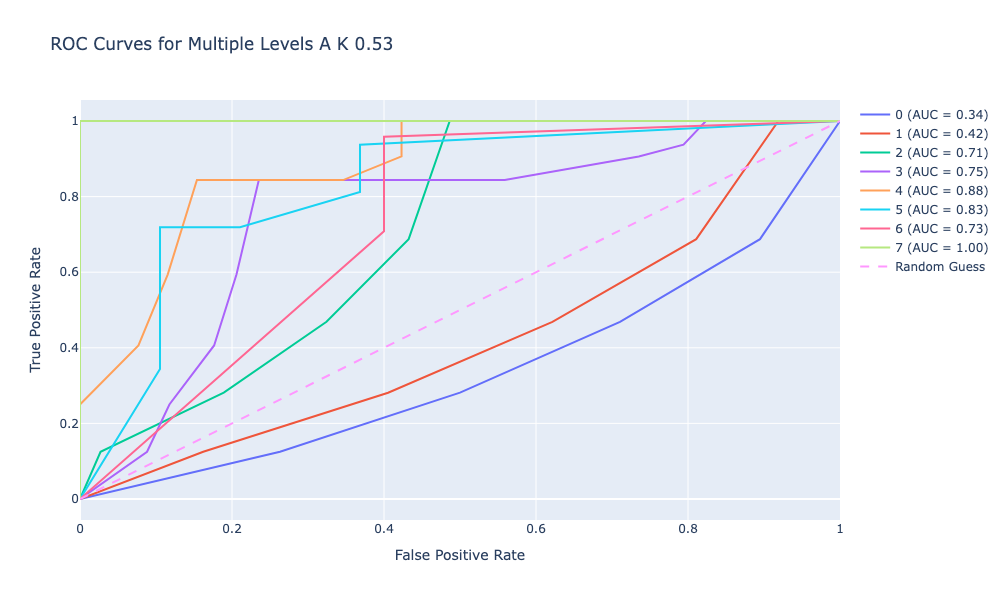

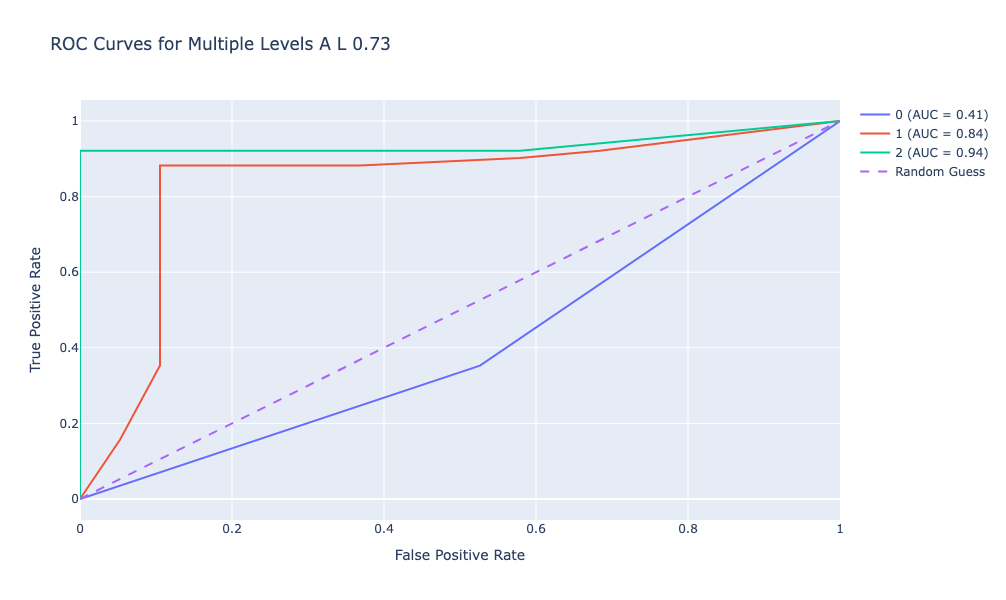

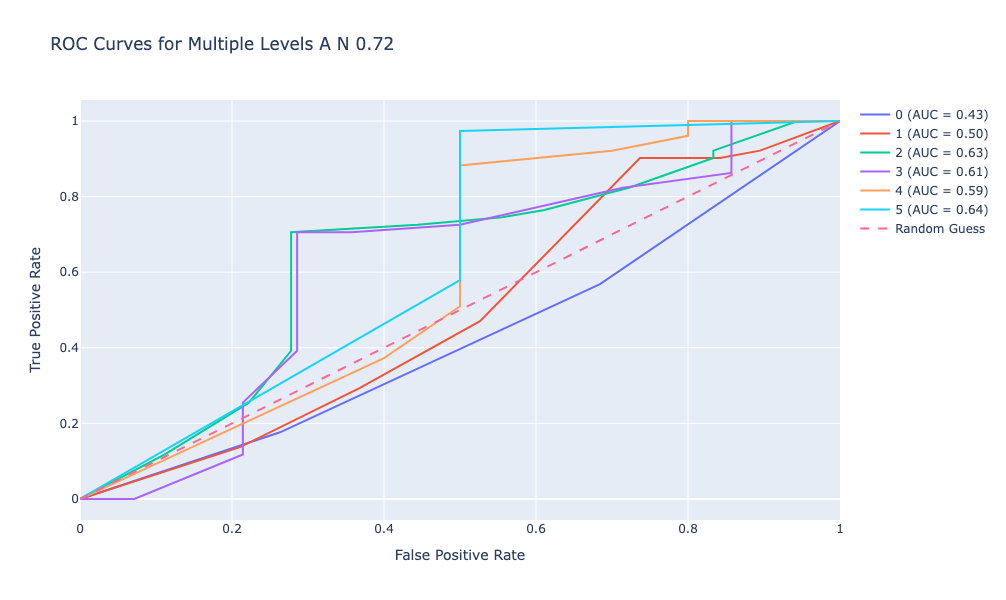

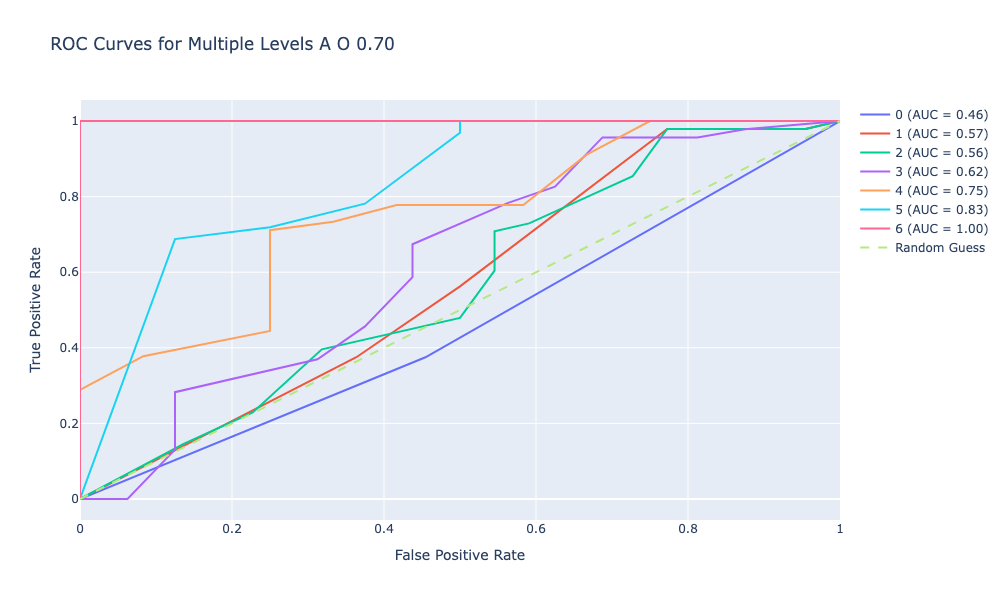

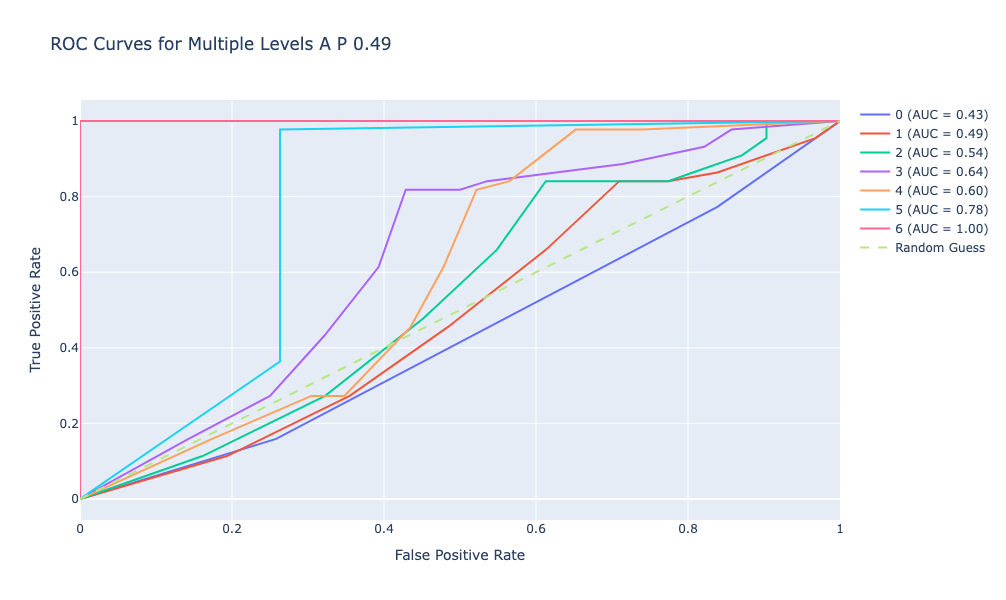

{0: [0.41894127377998347, 0.3388157894736842, 0.41331269349845207, 0.4277605779153767, 0.4602272727272727, 0.43401759530791784], 1: [0.7233250620347395, 0.42229729729729726, 0.8369453044375644, 0.49742002063983487, 0.5653409090909091, 0.49156891495601174], 2: [0.8726220016542597, 0.7069256756756757, 0.9380804953560371, 0.6345315904139435, 0.5648674242424243, 0.5392228739002933], 3: [0.9052287581699346, 0.7527573529411764, 0.6134453781512605, 0.6243206521739131, 0.6375811688311688], 4: [1.0, 0.8786057692307692, 0.5931372549019608, 0.749074074074074, 0.5978260869565217], 5: [1.0, 0.8264802631578947, 0.6381578947368421, 0.833984375, 0.7763157894736843], 6: [0.7291666666666667, 1.0, 1.0], 7: [1.0]}


In [186]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from plotly.subplots import make_subplots

from sklearn.model_selection import StratifiedKFold


train, test = train_test_split(df, test_size=0.3)

flow_trees = []

# Initialize a 12x6 grid for 72 subplots (12 columns and 6 rows)
rows = 6
cols = 12
total_plots = 72

# Create subplots with space for 72 ROC plots
sp_titles = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    sp_titles.append(f"{start_node} {end_node} {group['path_mean_acc'].iloc[0]:.2f}")
fig = make_subplots(rows=rows, cols=cols, subplot_titles=sp_titles)


count = 0
plot_xs = []
plot_ys = []
accs = []
aucs_by_level = {}

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    # Train / test split
    this_path_df = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node)]


    # Calculate ROC and AUC for each model
    roc_data = {}
    px = []
    py = []

    likelihoods_by_level_by_person = {}
    actual_accuracies_by_level_by_person = {}
    
    for k in range(5):
        
    
        train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=k)

        # Compute Flow Tree for train
        G = do_reeb_for_df(train_this_path_df, use_turns=False) # 0 means all quartiles
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    
        # Visualise
        # plot_treeb(G)
    
    
        # Identify where one person's path is through the Flow Tree
        for _, plus_one in test_this_path_df.iterrows():
            special_subject_number = plus_one["Subject"]
    
            train_this_path_df_plus_one = pd.concat([train_this_path_df, pd.DataFrame([plus_one])])
            # print(special_subject_number, train_this_path_df_plus_one[["StartAt", "EndAt", "Subject"]])
            G_plus_one, special_visits, likelihoods_by_level = track_indiv_through_flow_tree(train_this_path_df_plus_one, special_subject_number, use_turns=False, DEBUG=False)

            for j, lik in enumerate(likelihoods_by_level):
                actual_acc = int(plus_one["accuracy"])
                if j in likelihoods_by_level_by_person:
                    likelihoods_by_level_by_person[j].append(lik)
                    actual_accuracies_by_level_by_person[j].append(actual_acc)
                else:
                    likelihoods_by_level_by_person[j] = [lik]
                    actual_accuracies_by_level_by_person[j] = [actual_acc]

            
            # print(G_plus_one.nodes)
            # print("Special visits", special_visits)
            # print("Likelihoods", likelihoods_by_level)
            # print(plus_one["accuracy"], collapse_traj(plus_one["paths"].split()))
    
            special_edges = [(special_visits[sv-1], special_visits[sv]) for sv in range(1, len(special_visits))]
            # plot_treeb_special_path(G_plus_one, special_edges)
            # break
                
        fig = go.Figure()

    # print("HI",[len(likelihoods_by_level_by_person[x]) for x in likelihoods_by_level_by_person])
    # break
    # print(likelihoods_by_level_by_person)
    # print(actual_accuracies_by_level_by_person)
    for i in likelihoods_by_level_by_person:
        # y_prob = []
        # this_y_test = []
        # for j, lik in likelihoods_by_level_by_person.items():
        #     if i < len(lik) and not pd.isna(lik[i]):
        #         y_prob.append(lik[i])
        #         this_y_test.append(y_test[j])
        # if len(this_y_test) == 0 or len(set(this_y_test)) == 1:
        #     continue
        # # print(this_y_test)
        # # print(y_prob)

        y_prob, this_y_test = [], []
        for x in range(len(likelihoods_by_level_by_person[i])):
            if not pd.isna(likelihoods_by_level_by_person[i][x]):
                y_prob.append(likelihoods_by_level_by_person[i][x])
                this_y_test.append(actual_accuracies_by_level_by_person[i][x])
        
        # print("YP", i, this_y_test, y_prob)

        # gonna be illegal to do ROC
        if len(this_y_test) == 0 or len(set(this_y_test)) == 1:
            continue

        fpr, tpr, _ = roc_curve(this_y_test, y_prob)
        auc = roc_auc_score(this_y_test, y_prob)
        roc_data[i] = (fpr, tpr, auc)

        px.append(i)
        py.append(auc)

        if i in aucs_by_level:
            aucs_by_level[i].append(auc)
        else:
            aucs_by_level[i] = [auc]            

        # print(fpr, tpr, auc)
        # print(len(this_y_test), np.mean(this_y_test))

    # print(aucs_by_level)
    # break
    plot_xs.append(aucs_by_level.keys())
    plot_ys.append([np.mean(aucs_by_level[i]) for i in aucs_by_level])
    accs.append(group['path_mean_acc'].iloc[0])
        
    # # Create an interactive ROC plot using Plotly
    # fig = go.Figure()
    row = (count // cols) + 1
    col = (count % cols) + 1

    # Add ROC curves for each model
    for model_name, (fpr, tpr, auc) in roc_data.items():
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} (AUC = {auc:.2f})'))#, row=row, col=col)    # Add ROC curves to the respective subplot
            
    
    # Add a diagonal reference line (random guess line)
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random Guess'))#, row=row, col=col)
    
    # Customize the layout
    fig.update_layout(
        title=f"ROC Curves for Multiple Levels {start_node} {end_node} {group['path_mean_acc'].iloc[0]:.2f}",
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        showlegend=True,
        width=800,
        height=600
    )
    
    # Show the plot
    fig.show()



    count += 1
    if count >5:
        # Now we need to do counts for each 
        break

# fig.update_layout(height=1500, width=3000, title_text="72 ROC Curves in Subplots", showlegend=False)
# fig.show()

print(aucs_by_level)

In [180]:
print([len(aucs_by_level[l]) for l in aucs_by_level])

[72, 72, 72, 71, 68, 65, 33, 14, 6, 1]


In [181]:
# print(accs)

[0.5454545454545454, 0.5303030303030303, 0.7285714285714285, 0.7164179104477612, 0.696969696969697, 0.4861111111111111, 0.625, 0.5294117647058824, 0.5694444444444444, 0.5303030303030303, 0.5135135135135135, 0.7864077669902912, 0.6515151515151515, 0.46875, 0.6617647058823529, 0.5211267605633803, 0.5147058823529411, 0.5970149253731343, 0.5915492957746479, 0.7285714285714285, 0.746031746031746, 0.44776119402985076, 0.6714285714285714, 0.5294117647058824, 0.640625, 0.5735294117647058, 0.5833333333333334, 0.7272727272727273, 0.6376811594202898, 0.5, 0.676923076923077, 0.5142857142857142, 0.5714285714285714, 0.6119402985074627, 0.5735294117647058, 0.5606060606060606, 0.7058823529411765, 0.5303030303030303, 0.6111111111111112, 0.34328358208955223, 0.4461538461538462, 0.5285714285714286, 0.5882352941176471, 0.53125, 0.7575757575757576, 0.3888888888888889, 0.6521739130434783, 0.421875, 0.5454545454545454, 0.6388888888888888, 0.5915492957746479, 0.5571428571428572, 0.765625, 0.5970149253731343, 

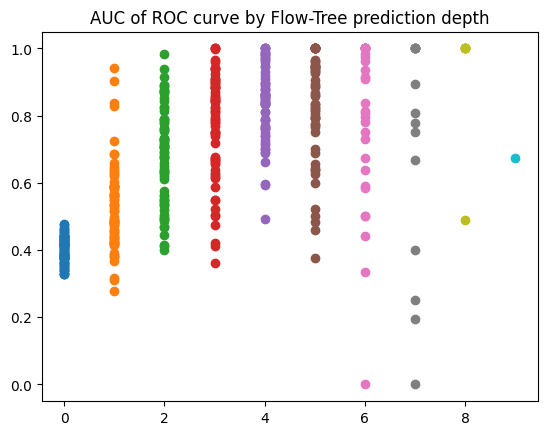

In [184]:
for l in aucs_by_level:
    xs, ys, c = [l for i in aucs_by_level[l]], aucs_by_level[l], accs[i]
    # if c < 0.5:
    #     col = "red"
    # elif c < 0.6:
    #     col = "orange"
    # else: 
    #     col = "green"
    plt.scatter(xs, ys)#, c=col, alpha=0.7)
plt.title("AUC of ROC curve by Flow-Tree prediction depth")
plt.show()